In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!wget https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/125/original/aerofit_treadmill.csv?1639992749

--2024-02-03 05:07:40--  https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/125/original/aerofit_treadmill.csv?1639992749
Resolving d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)... 108.157.172.10, 108.157.172.176, 108.157.172.183, ...
Connecting to d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)|108.157.172.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7279 (7.1K) [text/plain]
Saving to: ‘aerofit_treadmill.csv?1639992749’

aerofit_treadmill.c 100%[===================>]   7.11K  --.-KB/s    in 0s      

2024-02-03 05:07:41 (1.79 GB/s) - ‘aerofit_treadmill.csv?1639992749’ saved [7279/7279]



In [ ]:
aerofit = pd.read_csv("aerofit_treadmill.csv?1639992749")

In [ ]:
aerofit

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47
...,...,...,...,...,...,...,...,...,...
175,KP781,40,Male,21,Single,6,5,83416,200
176,KP781,42,Male,18,Single,5,4,89641,200
177,KP781,45,Male,16,Single,5,5,90886,160
178,KP781,47,Male,18,Partnered,4,5,104581,120


# Check for duplicates and null values

In [ ]:
aerofit.shape

(180, 9)

In [ ]:
aerofit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [ ]:
#Check for duplicates
aerofit.duplicated().sum()

0

In [ ]:
#Check for null values
aerofit.isna().sum()

Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitness          0
Income           0
Miles            0
dtype: int64

Insights:


1.   There shape of the aerofit dataframe is 180X9 i.e., it has 180 rows and 9 columns.
2.   There are no null values in the dataset.
3.   There are no duplicated entry in the dataset.



# Statistical Description

In [ ]:
aerofit.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


Insights:


*   Age : The avg age is around 29 years.
*   Education : Customer education varies between 12 and 21 years with avg eduction value as 16 years.
*   Usage : Customer use 3.45 times on an avg each week.
*   Fitness : Customer are realatively fit with mean around 3.3
*   Income : Avg income of customer is arounf 54K USD with min income as 30K USD and max income 10K+ USD.
*   Miles : The customer walk/run 103 miles each week on an avg.



# Pre-Processing of data:

In [ ]:
# Get unique values
for col in aerofit.columns:
  #print (aerofit[col].dtype)
  if aerofit[col].dtype == 'int64':
    print("Unique value for ",col," : ",np.sort(aerofit[col].unique()))
  else:
    print("Unique value for ",col," : ",aerofit[col].unique())
  print("Total Unique values : ",aerofit[col].nunique())

Unique value for  Product  :  ['KP281' 'KP481' 'KP781']
Total Unique values :  3
Unique value for  Age  :  [18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41
 42 43 44 45 46 47 48 50]
Total Unique values :  32
Unique value for  Gender  :  ['Male' 'Female']
Total Unique values :  2
Unique value for  Education  :  [12 13 14 15 16 18 20 21]
Total Unique values :  8
Unique value for  MaritalStatus  :  ['Single' 'Partnered']
Total Unique values :  2
Unique value for  Usage  :  [2 3 4 5 6 7]
Total Unique values :  6
Unique value for  Fitness  :  [1 2 3 4 5]
Total Unique values :  5
Unique value for  Income  :  [ 29562  30699  31836  32973  34110  35247  36384  37521  38658  39795
  40932  42069  43206  44343  45480  46617  47754  48556  48658  48891
  49801  50028  51165  52290  52291  52302  53439  53536  54576  54781
  55713  56850  57271  57987  58516  59124  60261  61006  61398  62251
  62535  64741  64809  65220  67083  68220  69721  70966  74701  75946
  77191  83

Adding new columns to categorize the data properly.

In [ ]:
#Divide the Age into Different age groups
# Age 18-26 : Young
# Age 27-37 : Young Adult
# Age 37-46 : Adult
# Age >=47 : Elder

def age_group(Gender):
  if Gender >= 18 and Gender <=26:
    return "Young"
  elif Gender >= 27 and Gender <=37:
    return "Young Adult"
  elif Gender >= 37 and Gender <=46:
    return "Adult"
  else:
    return "Elder"

In [ ]:
aerofit["Age_Group"] = aerofit['Age'].apply(age_group)

In [ ]:
#Divide the Education into Different age groups
# Education <15 : Primary
# Education>=15 and <=18 : Secondary
# Education>18 : High
def edu_group(Education):
  if Education <15:
    return "Primary"
  elif Education >= 16 and Education <=18:
    return "Secondary"
  else:
    return "High"

In [ ]:
aerofit["Education_Group"] = aerofit['Education'].apply(edu_group)

In [ ]:
#Divide the Fitness into Different age groups
# Fitness <=2 : Poor Shape
# Fitness >=3 and <=4 : Avg Shape
# Fitness ==5 : Execellent Shape
def fit_group(Fitness):
  if Fitness <3:
    return "Poor Shape"
  elif Fitness >= 3 and Fitness <=4:
    return "Avg Shape"
  else:
    return "Execellent Shape"

In [ ]:
aerofit["Fitness_Group"] = aerofit['Fitness'].apply(fit_group)

In [ ]:
#Divide the Income into Different age groups
# Income <=50K USD : Low Income
# Fitness >50K USD and <=75K UsD : Avg Income
# Fitness > 75K USD : High Income
def inc_group(Income):
  if Income <= 50000:
    return "Low Income"
  elif Income > 50000 and Income <=75000:
    return "Avg Income"
  else:
    return "High Income"

In [ ]:
aerofit["Income_Group"] = aerofit['Income'].apply(inc_group)

In [ ]:
#Divide the Usage into Different Avg Usage/week groups
# Usage >=2 and <=3 : Low Avg_Usage/week
# Usage >=4 and <=5 : Medium Avg_Usage/week
# Usage >=6 and <=7 : High Avg_Usage/week
def usg_group(Usage):
  if Usage>=2 and Usage<=3:
    return "Low Avg_Usage/week"
  elif Usage>=4 and Usage<=5:
    return "Medium Avg_Usage/week"
  else:
    return "High Avg_Usage/week"

In [ ]:
aerofit["Avg Usage/week_Group"] = aerofit['Usage'].apply(usg_group)

In [ ]:
aerofit

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_Group,Education_Group,Fitness_Group,Income_Group,Avg Usage/week_Group
0,KP281,18,Male,14,Single,3,4,29562,112,Young,Primary,Avg Shape,Low Income,Low Avg_Usage/week
1,KP281,19,Male,15,Single,2,3,31836,75,Young,High,Avg Shape,Low Income,Low Avg_Usage/week
2,KP281,19,Female,14,Partnered,4,3,30699,66,Young,Primary,Avg Shape,Low Income,Medium Avg_Usage/week
3,KP281,19,Male,12,Single,3,3,32973,85,Young,Primary,Avg Shape,Low Income,Low Avg_Usage/week
4,KP281,20,Male,13,Partnered,4,2,35247,47,Young,Primary,Poor Shape,Low Income,Medium Avg_Usage/week
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,KP781,40,Male,21,Single,6,5,83416,200,Adult,High,Execellent Shape,High Income,High Avg_Usage/week
176,KP781,42,Male,18,Single,5,4,89641,200,Adult,Secondary,Avg Shape,High Income,Medium Avg_Usage/week
177,KP781,45,Male,16,Single,5,5,90886,160,Adult,Secondary,Execellent Shape,High Income,Medium Avg_Usage/week
178,KP781,47,Male,18,Partnered,4,5,104581,120,Elder,Secondary,Execellent Shape,High Income,Medium Avg_Usage/week


# Graphical Analyis

## Univariate Analysis

### Categorical Values

Product vs Sales

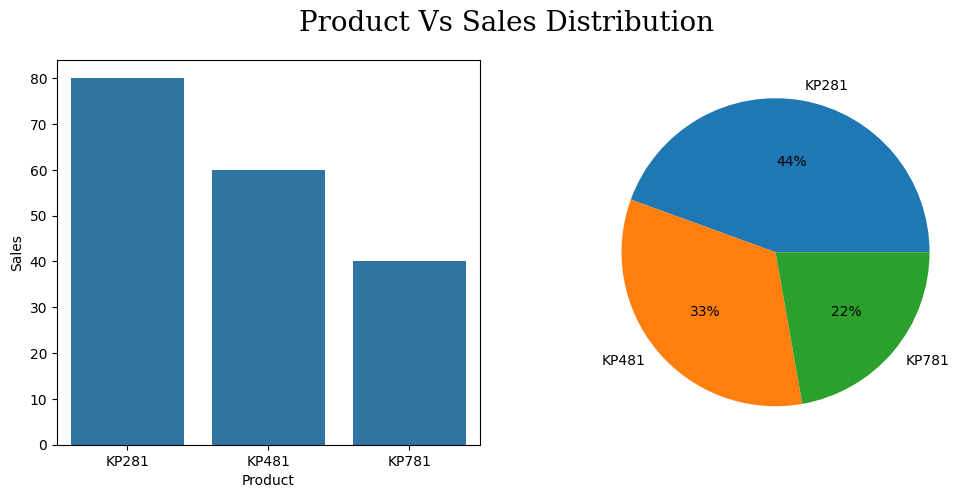

In [ ]:
df1 = aerofit
plt.figure(figsize=(12,5))
font1 = {'family':'serif','color':'Black'}
plt.suptitle("Product Vs Sales Distribution",fontdict = font1,fontsize = 20)

plt.subplot(1,2,1)

bar = sns.countplot(data=df1, x='Product')

plt.ylabel("Sales")

plt.subplot(1,2,2)
values = df1['Product'].value_counts()
plt.pie(values, labels = df1['Product'].value_counts().index, autopct = "%.f%%")


plt.show()

Insights:


*   KP281 is sold more among the people. It covers 44% of the total sales.
*   KP481 and KP781 occupies the 2nd and 3rd places in respect of sales.


Gender Distibution

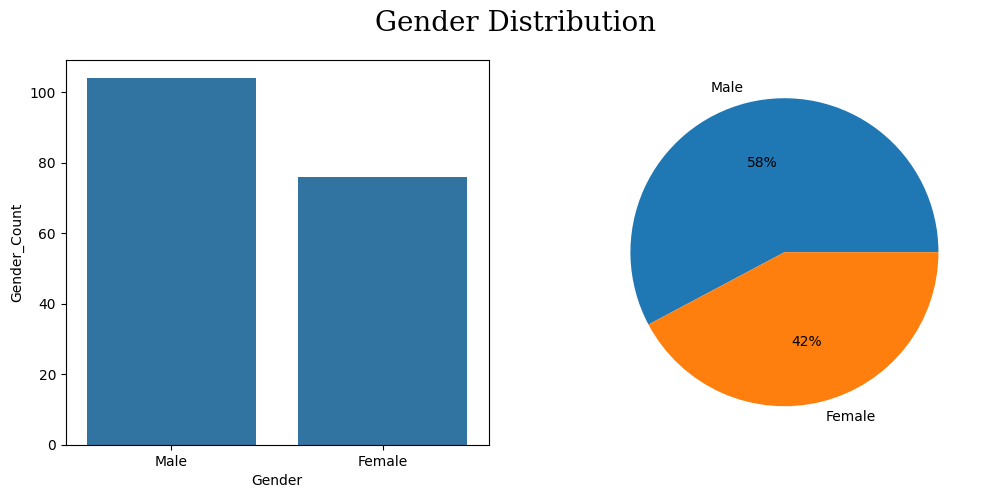

In [ ]:
df1 = aerofit
plt.figure(figsize=(12,5))
font1 = {'family':'serif','color':'Black'}
plt.suptitle("Gender Distribution",fontdict = font1,fontsize = 20)

plt.subplot(1,2,1)

bar = sns.countplot(data=df1, x='Gender')

plt.ylabel("Gender_Count")

plt.subplot(1,2,2)
values = df1['Gender'].value_counts()
plt.pie(values, labels = df1['Gender'].value_counts().index, autopct = "%.f%%")


plt.show()

Insights:


*   Male gender are likely to be more enthusiast in buying products from Aerofit than females. Male occupies 58% of the total product sold.



MaritalStatus Distribution

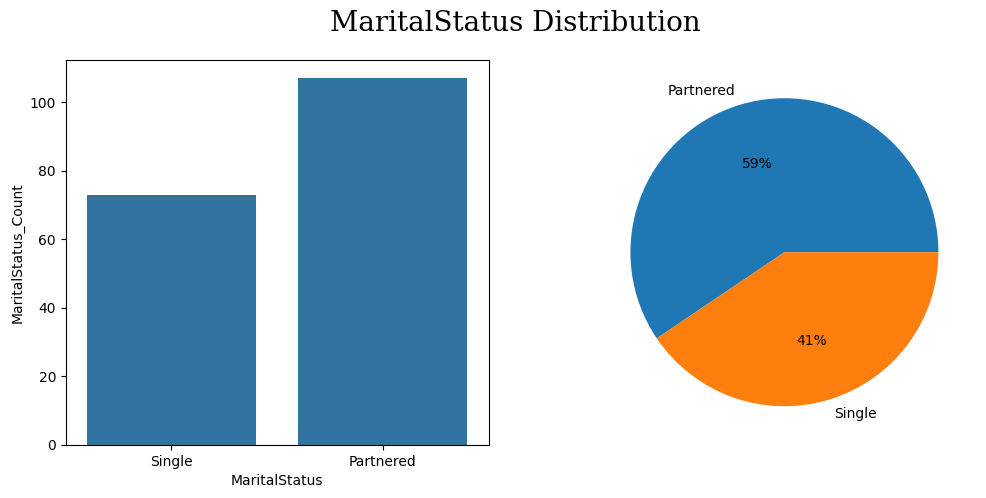

In [ ]:
df1 = aerofit
plt.figure(figsize=(12,5))
font1 = {'family':'serif','color':'Black'}
plt.suptitle("MaritalStatus Distribution",fontdict = font1,fontsize = 20)

plt.subplot(1,2,1)

bar = sns.countplot(data=df1, x='MaritalStatus')

plt.ylabel("MaritalStatus_Count")

plt.subplot(1,2,2)
values = df1['MaritalStatus'].value_counts()
plt.pie(values, labels = df1['MaritalStatus'].value_counts().index, autopct = "%.f%%")


plt.show()

Insights:


*   Couples/partnered are likely to be more enthusiast in buying products from Aerofit than singles. Male occupies 58% of the total product sold.

Age_Group Distribution

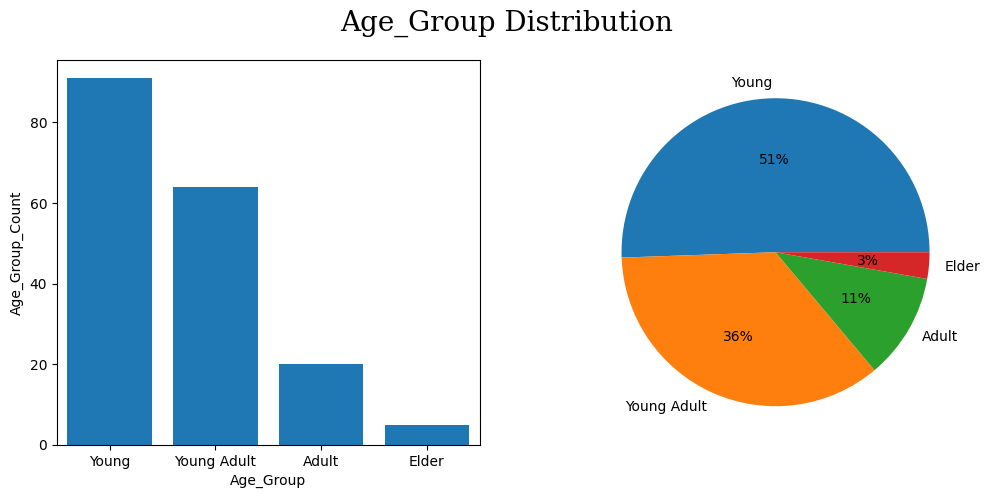

In [ ]:
df1 = aerofit
plt.figure(figsize=(12,5))
font1 = {'family':'serif','color':'Black'}
plt.suptitle("Age_Group Distribution",fontdict = font1,fontsize = 20)

plt.subplot(1,2,1)

bar = sns.countplot(data=df1, x='Age_Group',saturation = 1)

plt.ylabel("Age_Group_Count")

plt.subplot(1,2,2)
values = df1['Age_Group'].value_counts()
plt.pie(values, labels = df1['Age_Group'].value_counts().index, autopct = "%.f%%")


plt.show()

Insights:

*    Young people(Age 18-26) are the highest buyers(51%) from Aerofit while elder people(Age >=47) are the least buyers(3%).
*     Young adult(Age 27-37) and Adult(Age 38-46) occupies the 2nd and 3rd position.  

Fitness_Group Distribution

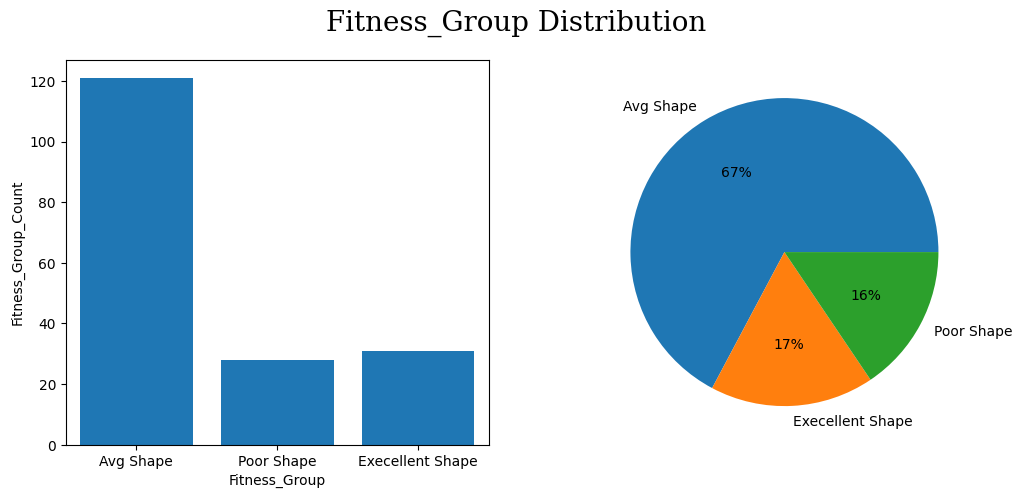

In [ ]:
df1 = aerofit
plt.figure(figsize=(12,5))
font1 = {'family':'serif','color':'Black'}
plt.suptitle("Fitness_Group Distribution",fontdict = font1,fontsize = 20)

plt.subplot(1,2,1)

bar = sns.countplot(data=df1, x='Fitness_Group',saturation = 1)

plt.ylabel("Fitness_Group_Count")

plt.subplot(1,2,2)
values = df1['Fitness_Group'].value_counts()
plt.pie(values, labels = df1['Fitness_Group'].value_counts().index, autopct = "%.f%%")


plt.show()

Insights:


*   Most people are avg fit(fit rating b/w 3 and 4(both inclusive)) and they make 67% of the total distribution of people who bought products from Aerofit.
*   The difference between Execellent fit(fitness rating = 5) and Poor shape(fitness rating <= 2) is only 1%.



### Numerical Analysis

In [ ]:
aerofit

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_Group,Education_Group,Fitness_Group,Income_Group,Avg Usage/week_Group
0,KP281,18,Male,14,Single,3,4,29562,112,Young,Primary,Avg Shape,Low Income,Low Avg_Usage/week
1,KP281,19,Male,15,Single,2,3,31836,75,Young,High,Avg Shape,Low Income,Low Avg_Usage/week
2,KP281,19,Female,14,Partnered,4,3,30699,66,Young,Primary,Avg Shape,Low Income,Medium Avg_Usage/week
3,KP281,19,Male,12,Single,3,3,32973,85,Young,Primary,Avg Shape,Low Income,Low Avg_Usage/week
4,KP281,20,Male,13,Partnered,4,2,35247,47,Young,Primary,Poor Shape,Low Income,Medium Avg_Usage/week
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,KP781,40,Male,21,Single,6,5,83416,200,Adult,High,Execellent Shape,High Income,High Avg_Usage/week
176,KP781,42,Male,18,Single,5,4,89641,200,Adult,Secondary,Avg Shape,High Income,Medium Avg_Usage/week
177,KP781,45,Male,16,Single,5,5,90886,160,Adult,Secondary,Execellent Shape,High Income,Medium Avg_Usage/week
178,KP781,47,Male,18,Partnered,4,5,104581,120,Elder,Secondary,Execellent Shape,High Income,Medium Avg_Usage/week


Age

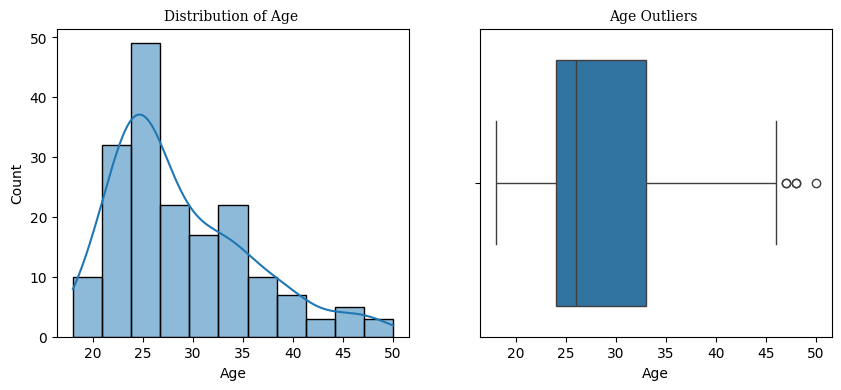

In [ ]:
df1 = aerofit
plt.figure(figsize=(10,4))
font1 = {'family':'serif','color':'Black'}
ax1=plt.subplot(1,2,1)
sns.histplot(data=df1, x=df1['Age'], kde=True)
ax1.set_title("Distribution of Age ",fontdict = font1,fontsize = 10)

ax2 = plt.subplot(1,2,2)
boxplot1 =sns.boxplot(data=df1, x='Age', orient='h')
ax2.set_title("Age Outliers ",fontdict = font1,fontsize = 10)
plt.show()

Insights:


*   Median age is around 25 years.
*   There are 3 outliers in the age group.



Education

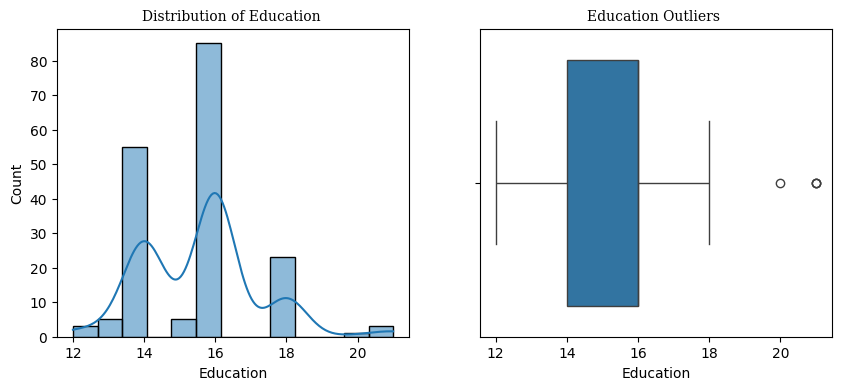

In [ ]:
df1 = aerofit
plt.figure(figsize=(10,4))
font1 = {'family':'serif','color':'Black'}
ax1=plt.subplot(1,2,1)
sns.histplot(data=df1, x=df1['Education'], kde=True)
ax1.set_title("Distribution of Education ",fontdict = font1,fontsize = 10)

ax2 = plt.subplot(1,2,2)
boxplot1 =sns.boxplot(data=df1, x='Education', orient='h')
ax2.set_title("Education Outliers ",fontdict = font1,fontsize = 10)
plt.show()

Insights:


*   Most of the customers have around 16 years of .
*   We can see 2 outliers in the age Education field.

Income

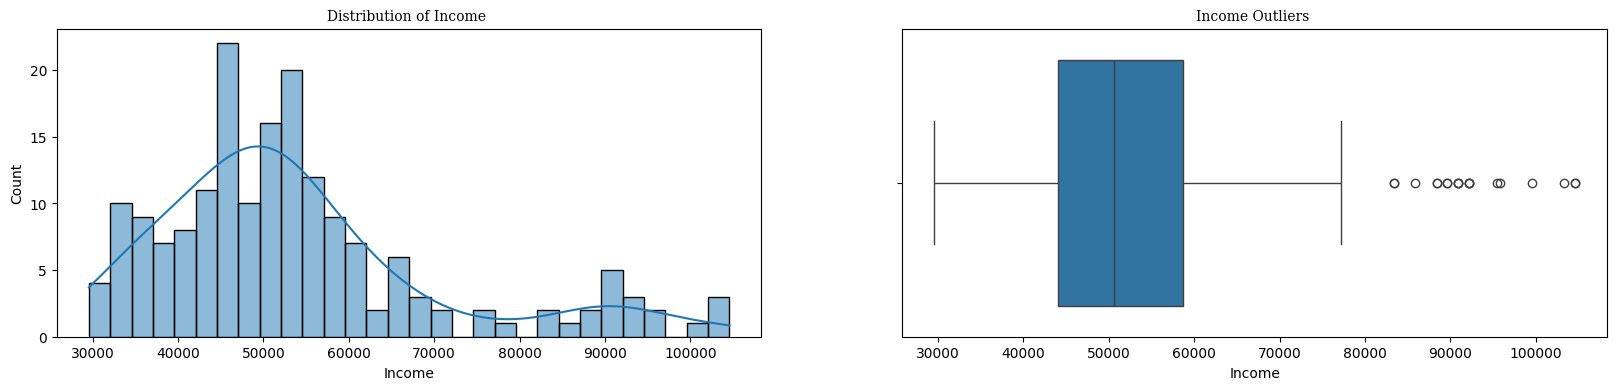

Avg Income :  53719.57777777778


In [ ]:
df1 = aerofit
plt.figure(figsize=(20,4))
font1 = {'family':'serif','color':'Black'}
ax1=plt.subplot(1,2,1)
sns.histplot(data=df1, x=df1['Income'], kde=True,bins=30)
ax1.set_title("Distribution of Income ",fontdict = font1,fontsize = 10)

ax2 = plt.subplot(1,2,2)
boxplot1 =sns.boxplot(data=df1, x='Income', orient='h')
ax2.set_title("Income Outliers ",fontdict = font1,fontsize = 10)
plt.show()
print("Avg Income : ",df1['Income'].mean())

Insights:


*   Avg income is 53719 USD where as median income is just above 50000 USD.
*   We can see there are many outliers in the age Education field.

##Bivariate Analysis

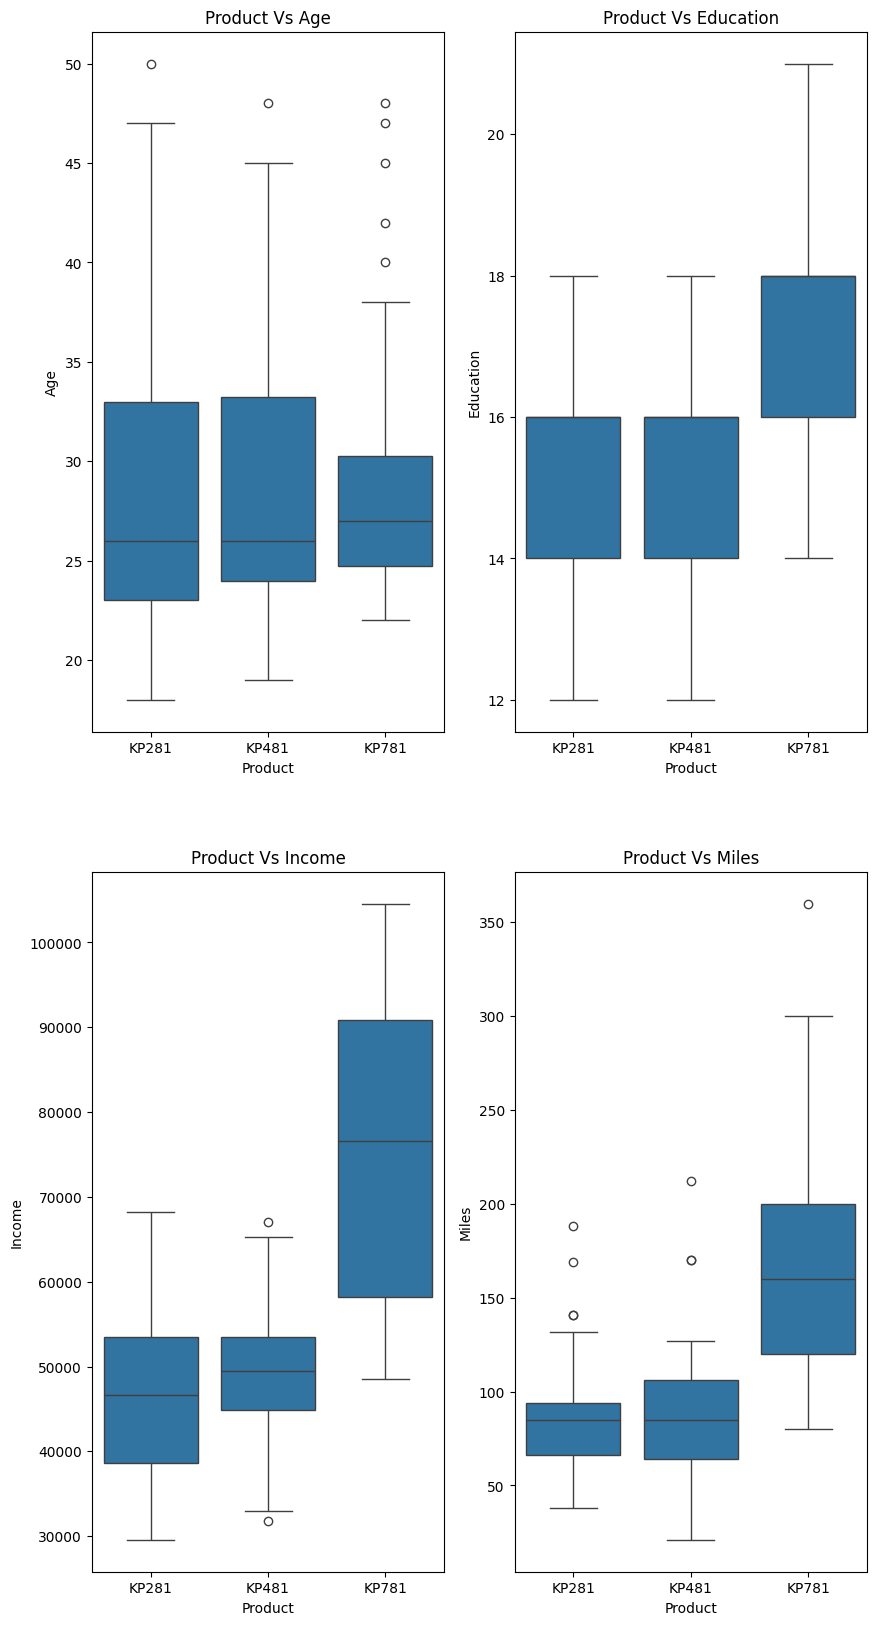

In [ ]:
# product vs age
plt.figure(figsize=(10,20))
ax1 = plt.subplot(2,2,1)
sns.boxplot(data=df1, x='Product', y='Age')
ax1.set_title("Product Vs Age")

# product vs Education
ax2 = plt.subplot(2,2,2)
sns.boxplot(data=df1, x='Product', y='Education')
ax2.set_title("Product Vs Education")

# product vs Income
ax3 = plt.subplot(2,2,3)
sns.boxplot(data=df1, x='Product', y='Income')
ax3.set_title("Product Vs Income")

# product vs Miles
ax4 = plt.subplot(2,2,4)
sns.boxplot(data=df1, x='Product', y='Miles')
ax4.set_title("Product Vs Miles")
plt.show()

Text(0.5, 1.0, 'Product w.r.t to Age_Group')

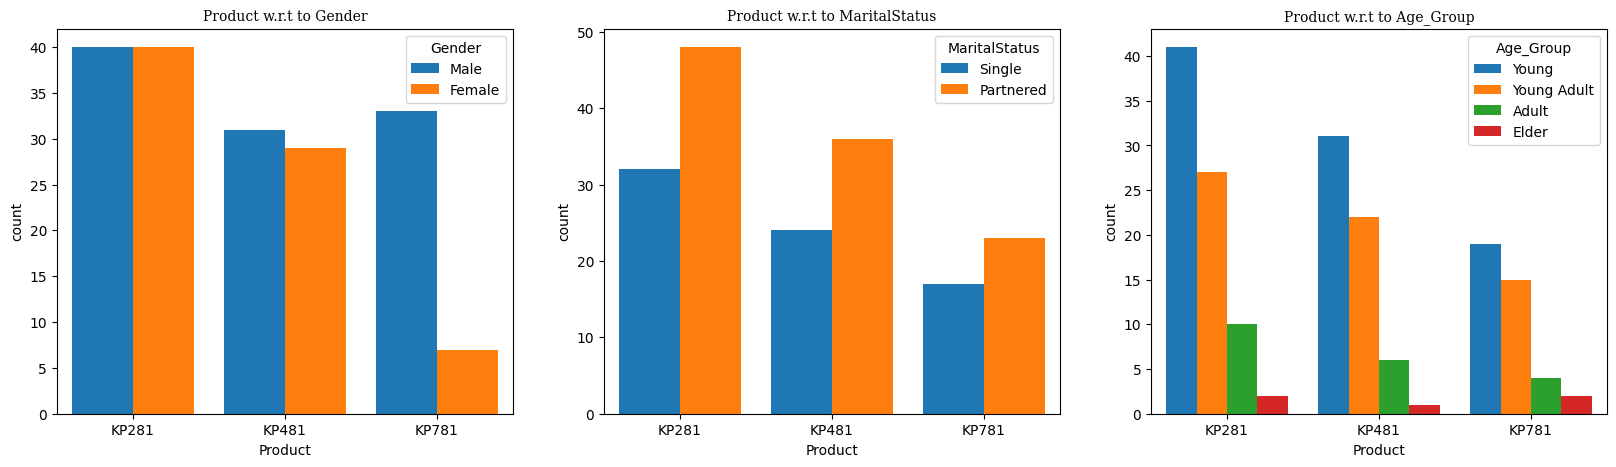

In [ ]:
df1 = aerofit
fig = plt.figure(figsize=(20,5))
font1 = {'family':'serif','color':'Black'}
ax = fig.add_subplot(131)
bar = sns.countplot(data=df1, x='Product',saturation = 1,hue = 'Gender')
ax.set_title("Product w.r.t to Gender",fontdict = font1,fontsize = 10)

ax1=fig.add_subplot(132)
bar1 = sns.countplot(data=df1, x='Product',saturation = 1,hue = 'MaritalStatus')
ax1.set_title("Product w.r.t to MaritalStatus",fontdict = font1,fontsize = 10)

ax2=fig.add_subplot(133)
bar2 = sns.countplot(data=df1, x='Product',saturation = 1,hue = 'Age_Group')
ax2.set_title("Product w.r.t to Age_Group",fontdict = font1,fontsize = 10)



Insights:


*   KP281
    *    It is equally popular between male and female.Partnered people also like this product and it is also popular among young generartion people as well.
*   KP481
    *    Male like this product more than female.Partnered people also like   
         this product.Young generartion people like this prodct than other generation.
*   KP781
    *    Male like this product more than female.Partnered people also like   
         this product.Young generartion people like this prodct than other generation.



Text(0.5, 1.0, 'Product w.r.t to Avg Usage/week_Group')

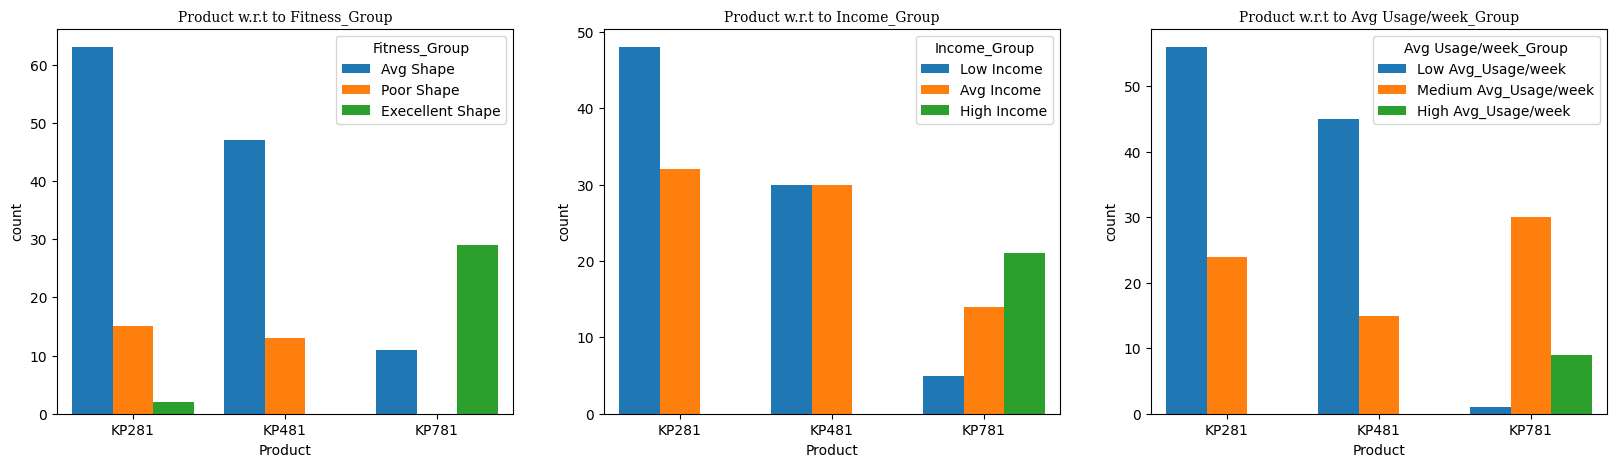

In [ ]:
fig = plt.figure(figsize=(20,5))
font1 = {'family':'serif','color':'Black'}
ax3=fig.add_subplot(131)
bar3 = sns.countplot(data=df1, x='Product',saturation = 1,hue = 'Fitness_Group')
ax3.set_title("Product w.r.t to Fitness_Group",fontdict = font1,fontsize = 10)

ax4=fig.add_subplot(132)
bar4 = sns.countplot(data=df1, x='Product',saturation = 1,hue = 'Income_Group')
ax4.set_title("Product w.r.t to Income_Group",fontdict = font1,fontsize = 10)

ax5=fig.add_subplot(133)
bar5 = sns.countplot(data=df1, x='Product',saturation = 1,hue = 'Avg Usage/week_Group')
ax5.set_title("Product w.r.t to Avg Usage/week_Group",fontdict = font1,fontsize = 10)

Insights:


*   KP281
    *    Low income group people like this product and theya are avg fit.
*   KP481
    *   Both low and avg income group people like this product and they are avg fit.
*   KP781
    *   High income group people like this product and those who use this product are fit.


# Correlation

Pairplot

<Figure size 500x500 with 0 Axes>

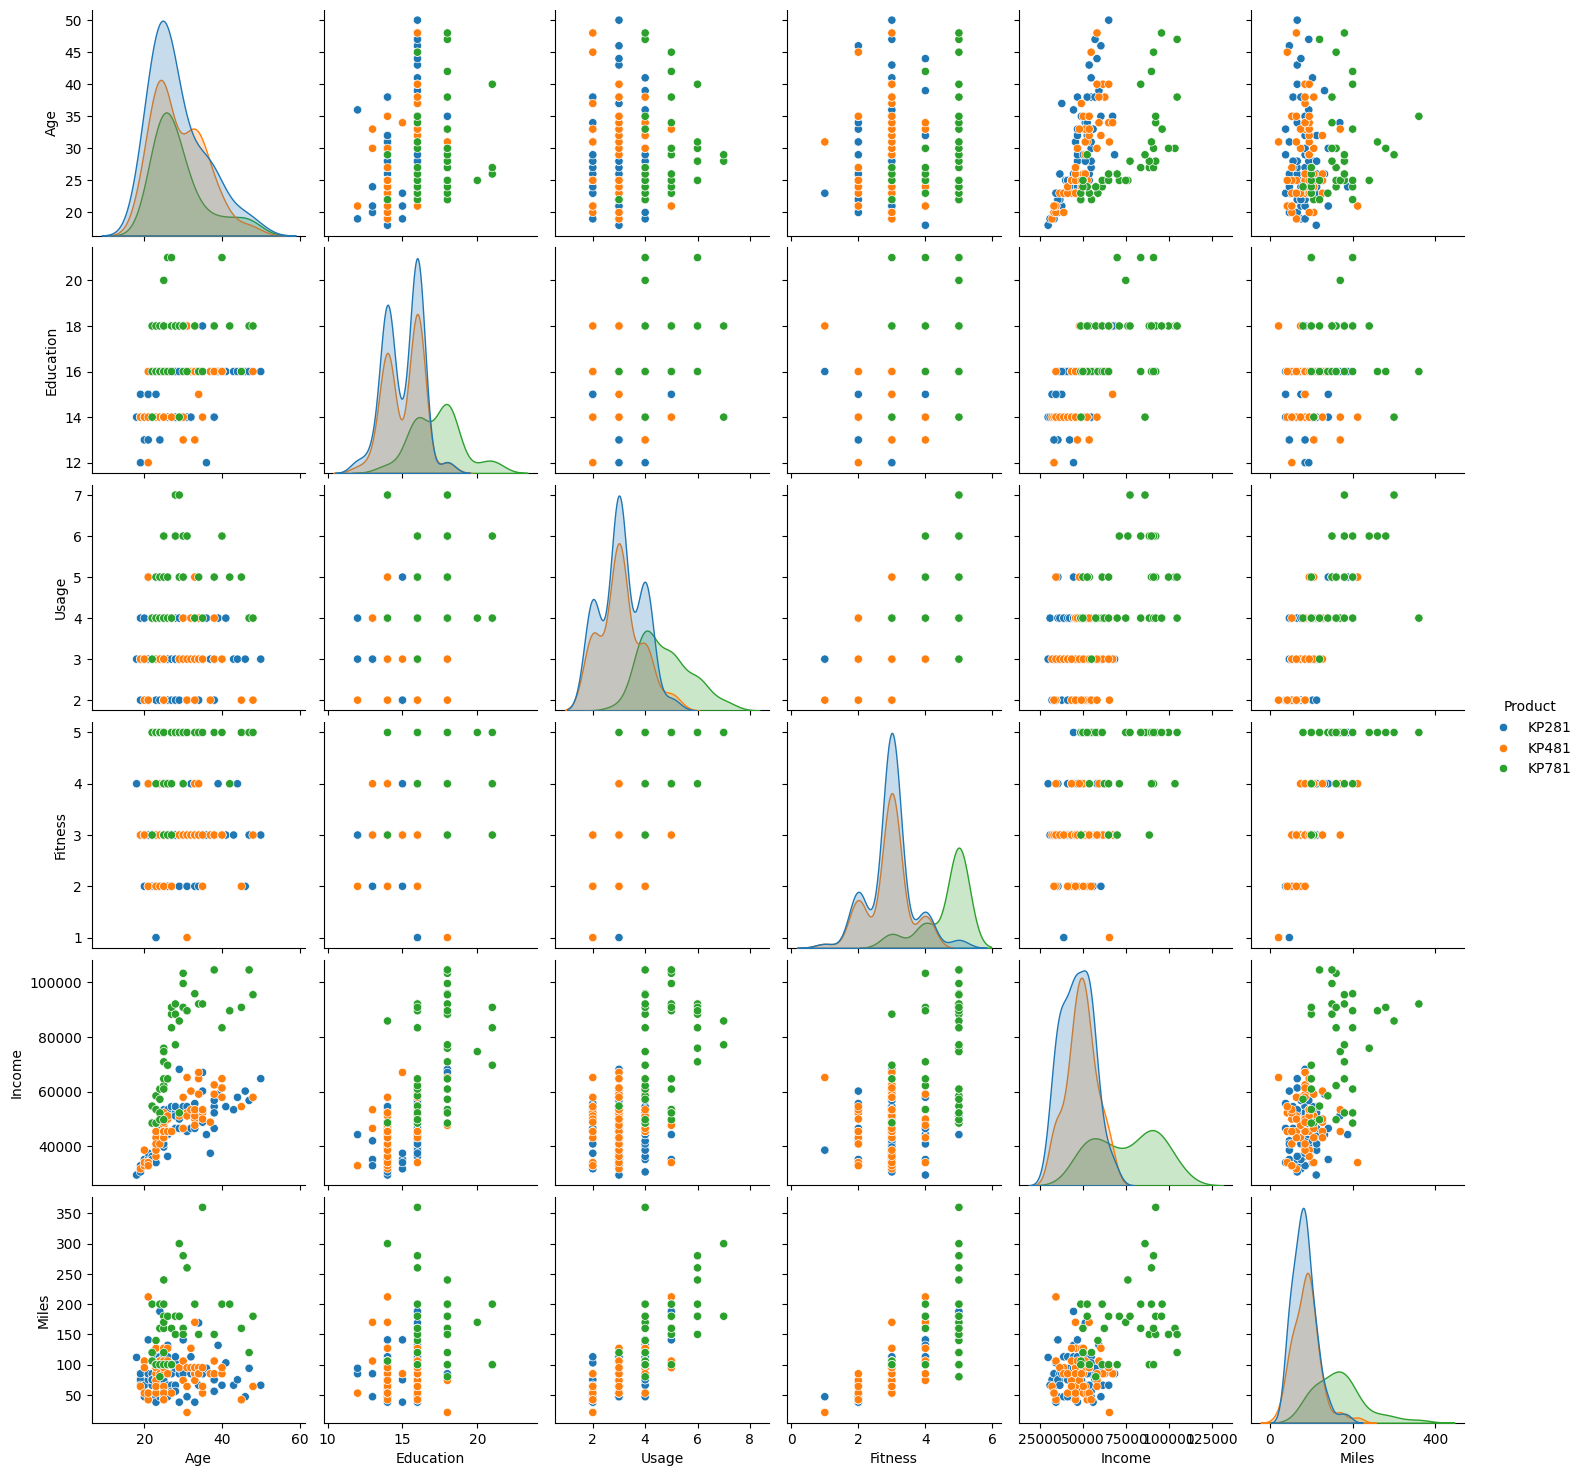

In [ ]:

plt.figure(figsize=(5,5))
sns.pairplot(aerofit, hue ='Product')
plt.show()

<ipython-input-36-3a42305771d1>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corelation_matrix = aerofit.corr()


<Axes: >

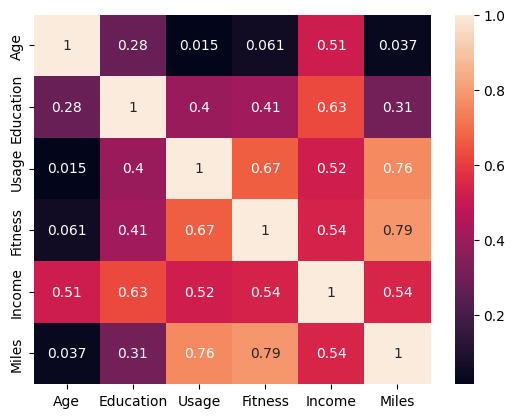

In [ ]:
corelation_matrix = aerofit.corr()
sns.heatmap(data = corelation_matrix,annot=True)

Insights:


*   Age and Income has positive corelation. ie as age increases the icome of the indivisual also increasing.
*   Fitness and Miles have the highest positive corelation.
*   As per the heat map we can see all are having postive corelation.
*   The age and usage have the least coreelation which indicates that age doenot playa ery sigficant impact on the usage of the treadmils.


#Probability

In [ ]:
#Probaility b/w Product and Age_Group
pd.crosstab(index=aerofit['Product'], columns = aerofit['Age_Group'], margins = True)


Age_Group,Adult,Elder,Young,Young Adult,All
Product,,,,,
KP281,10,2,41,27,80
KP481,6,1,31,22,60
KP781,4,2,19,15,40
All,20,5,91,64,180


Insights:


*   Probailty of treadmil being KP281 is 80/180 = .44
*   Probailty of treadmil being KP481 is 60/180 = .33
*   Probailty of treadmil being KP481 is 40/180 = .22
*   Conditional Probability:
    *    Product is KP281 given it is sold to adult  is 10/20 =.5
    *    Product is KP481 given it is sold to adult  is 6/20 = .3
    *    Product is KP781 given it is sold to adult  is 4/20 = .2
    *    Product is KP281 given it is sold to Elder  is 2/5 =.4
    *    Product is KP481 given it is sold to Elder  is 1/5 = .2
    *    Product is KP781 given it is sold to Elder  is 2/5 = .4
    *    Product is KP281 given it is sold to Young  is 41/91 = .45
    *    Product is KP481 given it is sold to Young  is 31/91 = .34
    *    Product is KP781 given it is sold to Young  is 19/91 = .21
    *    Product is KP281 given it is sold to Young Adult  is 27/64 = .42
    *    Product is KP481 given it is sold to Young Adult is 22/64 = .34
    *    Product is KP781 given it is sold to Young Adult is 15/64 = .24





In [ ]:
#Probaility b/w Product and Income_Group
pd.crosstab(index=aerofit['Product'], columns = aerofit['Income_Group'], margins = True)

Income_Group,Avg Income,High Income,Low Income,All
Product,,,,
KP281,32,0,48,80
KP481,30,0,30,60
KP781,14,21,5,40
All,76,21,83,180


Insights:


*   Probailty of treadmil being KP281 is 80/180 = .44
*   Probailty of treadmil being KP481 is 60/180 = .33
*   Probailty of treadmil being KP481 is 40/180 = .22
*   Conditional Probability:
    *    Product is KP281 given it is sold to Avg Income group  is 32/76 =.42
    *    Product is KP481 given it is sold to Avg Income group  is 30/76 = .39
    *    Product is KP781 given it is sold to Avg Income group  is 14/76 = .19
    *    Product is KP281 given it is sold to High Income group  is 0/21 = 0
    *    Product is KP481 given it is sold to High Income group  is 0/21= 0
    *    Product is KP781 given it is sold to High Income group  is 21/21 = 1
    *    Product is KP281 given it is sold to Low Income group  is 48/83 = .58
    *    Product is KP481 given it is sold to Low Income group  is 30/83 = .36
    *    Product is KP781 given it is sold to Low Income group  is 5/83 = 0.06


In [ ]:
#Probaility b/w Product and Gender
pd.crosstab(index=aerofit['Product'], columns = aerofit['Gender'], margins = True)

Gender,Female,Male,All
Product,,,
KP281,40,40,80
KP481,29,31,60
KP781,7,33,40
All,76,104,180


Insights:


*   Probailty of treadmil being KP281 is 80/180 = .44
*   Probailty of treadmil being KP481 is 60/180 = .33
*   Probailty of treadmil being KP481 is 40/180 = .22
*   Conditional Probability:
    *    Product is KP281 given it is sold to Male group  is 40/104 = .38
    *    Product is KP481 given it is sold to Male group  is 31/104 = .30
    *    Product is KP781 given it is sold to Male group  is 33/104 = .32
    *    Product is KP281 given it is sold to Female group  is 40/76 = .53
    *    Product is KP481 given it is sold to Female group  is 29/76 = .38
    *    Product is KP781 given it is sold to Female group  is 7/76 = .09


In [ ]:
#Probaility b/w Product and Marital Status Group
pd.crosstab(index=aerofit['Product'], columns = aerofit['MaritalStatus'], margins = True)

MaritalStatus,Partnered,Single,All
Product,,,
KP281,48,32,80
KP481,36,24,60
KP781,23,17,40
All,107,73,180


Insights:

*   Probailty of treadmil being KP281 is 80/180 = .44
*   Probailty of treadmil being KP481 is 60/180 = .33
*   Probailty of treadmil being KP481 is 40/180 = .22
*   Conditional Probability:
    *    Product is KP281 given it is sold to Partnered group  is 48/107 = .45
    *    Product is KP481 given it is sold to Partnered group  is 36/107 = .34
    *    Product is KP781 given it is sold to Partnered group  is 23/107 = .21
    *    Product is KP281 given it is sold to Single group  is 32/73 = .44
    *    Product is KP481 given it is sold to Single group  is 24/73 = .33
    *    Product is KP781 given it is sold to Single group  is 17/73 = .23

In [ ]:
#Probaility b/w Product and Fitness_Group
pd.crosstab(index=aerofit['Product'], columns = aerofit['Fitness_Group'], margins = True)

Fitness_Group,Avg Shape,Execellent Shape,Poor Shape,All
Product,,,,
KP281,63,2,15,80
KP481,47,0,13,60
KP781,11,29,0,40
All,121,31,28,180


Insights:

*   Probailty of treadmil being KP281 is 80/180 = .44
*   Probailty of treadmil being KP481 is 60/180 = .33
*   Probailty of treadmil being KP481 is 40/180 = .22
*   Conditional Probability:
    *    Product is KP281 given it is sold to Avg Shape group  is 63/121 = .52
    *    Product is KP481 given it is sold to Avg Shape group  is 47/121 = .39
    *    Product is KP781 given it is sold to Avg Shape group  is 11/121 = .09
    *    Product is KP281 given it is sold to Execellent Shape group  is 2/31 = .06
    *    Product is KP481 given it is sold to Execellent Shape group  is 0/31 = .0
    *    Product is KP781 given it is sold to Execellent Shape group  is 29/31 = .94
    *    Product is KP281 given it is sold to Poor Shape group  is 15/28 = .54
    *    Product is KP481 given it is sold to Poor Shape group  is 13/28 = .46
    *    Product is KP781 given it is sold to Poor Shape group  is 0/28 = .0

#Recommendations :


*   Product no KP781 is more popular in high income group people. Its a high end model and if the prices is reduced than it might be affordale to avg income group people  which will help in popularising it.
*   We can see unmarried people are buying less products so we can give discounts to them whcih will encourage them to buy the products.
*   Since male are more enthusiast in buying the products we can give them so offer which will create a strong customer support from them.
*   We can give some discounts to females to encourage them to buy products.
